In [1]:
# Cell 1: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')
import joblib

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
# Cell 2: Load and Explore the Dataset (
df = pd.read_csv('D:/Downloads/churn-bigml-80.csv')

# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nColumn Names:")
print(df.columns.tolist())
print("\nBasic Statistics:")
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (2666, 20)

First 5 rows:
  State  Account length  Area code International plan Voice mail plan  \
0    KS             128        415                 No             Yes   
1    OH             107        415                 No             Yes   
2    NJ             137        415                 No              No   
3    OH              84        408                Yes              No   
4    OK              75        415                Yes              No   

   Number vmail messages  Total day minutes  Total day calls  \
0                     25              265.1              110   
1                     26              161.6              123   
2                      0              243.4              114   
3                      0              299.4               71   
4                      0              166.7              113   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0             45.07              197.4               99   

Target Variable Distribution:
Churn
False    2278
True      388
Name: count, dtype: int64

Percentage:
Churn
False    85.446362
True     14.553638
Name: proportion, dtype: float64


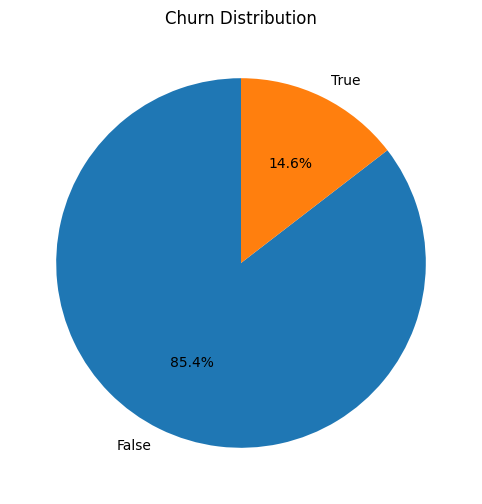


Data Types:
State                      object
Account length              int64
Area code                   int64
International plan         object
Voice mail plan            object
Number vmail messages       int64
Total day minutes         float64
Total day calls             int64
Total day charge          float64
Total eve minutes         float64
Total eve calls             int64
Total eve charge          float64
Total night minutes       float64
Total night calls           int64
Total night charge        float64
Total intl minutes        float64
Total intl calls            int64
Total intl charge         float64
Customer service calls      int64
Churn                        bool
dtype: object

Categorical Columns: ['State', 'International plan', 'Voice mail plan']
Numerical Columns: ['Account length', 'Area code', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', '

In [ ]:
# Cell 3: Data Preprocessing and Exploration
# Now we know the target column is 'Churn'
print("Target Variable Distribution:")
print(df['Churn'].value_counts())
print(f"\nPercentage:\n{df['Churn'].value_counts(normalize=True) * 100}")

# Visualize the target variable
plt.figure(figsize=(8, 6))
churn_counts = df['Churn'].value_counts()
plt.pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Churn Distribution')
plt.show()

# Check data types of columns
print("\nData Types:")
print(df.dtypes)

# Identify categorical and numerical columns
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
boolean_columns = df.select_dtypes(include=['bool']).columns.tolist()

print(f"\nCategorical Columns: {categorical_columns}")
print(f"Numerical Columns: {numerical_columns}")
print(f"Boolean Columns: {boolean_columns}")

# Note: 'Area code' should be treated as categorical
if 'Area code' in numerical_columns:
    numerical_columns.remove('Area code')
    categorical_columns.append('Area code')
    print("\nMoved 'Area code' from numerical to categorical")

In [ ]:
# Cell 4: Prepare Features and Target Variable (CORRECTED FOR YOUR DATASET)
# Separate features and target
X = df.drop(['Churn'], axis=1)  # Drop only the target column
y = df['Churn']  # Target variable (False/True)

# Convert target to binary (False -> 0, True -> 1)
y = y.astype(int)  # This will convert False to 0 and True to 1

# Identify numerical and categorical columns (updated based on your data)
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# Add boolean columns to categorical (they need encoding)
boolean_features = X.select_dtypes(include=['bool']).columns.tolist()
categorical_features.extend(boolean_features)

# Remove 'Area code' from numerical and add to categorical (if not already done)
if 'Area code' in numerical_features:
    numerical_features.remove('Area code')
    categorical_features.append('Area code')

print("Numerical Features:", numerical_features)
print(f"Count: {len(numerical_features)}")
print("\nCategorical Features:", categorical_features)
print(f"Count: {len(categorical_features)}")
print(f"\nTotal Features: {len(numerical_features) + len(categorical_features)}")
print(f"\nTarget Distribution:\n{y.value_counts(normalize=True)}")

Numerical Features: ['Account length', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls']
Count: 15

Categorical Features: ['State', 'International plan', 'Voice mail plan', 'Area code']
Count: 4

Total Features: 19

Target Distribution:
Churn
0    0.854464
1    0.145536
Name: proportion, dtype: float64


In [8]:
# Cell 5: Create Preprocessing Pipelines
# Numerical pipeline
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Handle any missing values
    ('scaler', StandardScaler())  # Scale numerical features
])

# Categorical pipeline (will handle both object and boolean types)
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),  # Handle missing values
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))  # One-hot encode
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features),
        ('cat', categorical_pipeline, categorical_features)
    ])

print("Preprocessing Pipeline Created Successfully!")
print(f"Processing {len(numerical_features)} numerical features and {len(categorical_features)} categorical features")

Preprocessing Pipeline Created Successfully!
Processing 15 numerical features and 4 categorical features


In [9]:
# Cell 6: Split the Data
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")
print(f"\nTraining set churn distribution:")
print(y_train.value_counts(normalize=True))
print(f"\nTesting set churn distribution:")
print(y_test.value_counts(normalize=True))

Training set size: (2132, 19)
Testing set size: (534, 19)

Training set churn distribution:
Churn
0    0.854597
1    0.145403
Name: proportion, dtype: float64

Testing set churn distribution:
Churn
0    0.853933
1    0.146067
Name: proportion, dtype: float64


In [10]:
# Cell 7: Create Complete Pipelines for Different Models
# Pipeline for Logistic Regression
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

# Pipeline for Random Forest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

print("Model Pipelines Created:")
print("1. Logistic Regression Pipeline")
print("2. Random Forest Pipeline")

Model Pipelines Created:
1. Logistic Regression Pipeline
2. Random Forest Pipeline


In [11]:
# Cell 8: Define Hyperparameter Grids for GridSearchCV
# Parameter grid for Logistic Regression
lr_param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l2'],
    'classifier__solver': ['lbfgs', 'newton-cg', 'sag']
}

# Parameter grid for Random Forest
rf_param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 10, 20, 30],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__class_weight': ['balanced', None]
}

print("Hyperparameter Grids Defined:")
print("\nLogistic Regression Parameters:")
for key, value in lr_param_grid.items():
    print(f"  {key}: {value}")

print("\nRandom Forest Parameters:")
for key, value in rf_param_grid.items():
    print(f"  {key}: {value}")

Hyperparameter Grids Defined:

Logistic Regression Parameters:
  classifier__C: [0.01, 0.1, 1, 10, 100]
  classifier__penalty: ['l2']
  classifier__solver: ['lbfgs', 'newton-cg', 'sag']

Random Forest Parameters:
  classifier__n_estimators: [50, 100, 200]
  classifier__max_depth: [None, 10, 20, 30]
  classifier__min_samples_split: [2, 5, 10]
  classifier__min_samples_leaf: [1, 2, 4]
  classifier__class_weight: ['balanced', None]


In [12]:
# Cell 9: Perform GridSearchCV for Logistic Regression
print("Starting GridSearchCV for Logistic Regression...")
print("This may take a few minutes...")

lr_grid_search = GridSearchCV(
    lr_pipeline,
    lr_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Fit the grid search
lr_grid_search.fit(X_train, y_train)

print("\nLogistic Regression Grid Search Complete!")
print(f"Best Parameters: {lr_grid_search.best_params_}")
print(f"Best Cross-Validation Score: {lr_grid_search.best_score_:.4f}")

Starting GridSearchCV for Logistic Regression...
This may take a few minutes...
Fitting 5 folds for each of 15 candidates, totalling 75 fits

Logistic Regression Grid Search Complete!
Best Parameters: {'classifier__C': 0.1, 'classifier__penalty': 'l2', 'classifier__solver': 'sag'}
Best Cross-Validation Score: 0.8318


In [13]:
# Cell 10: Perform GridSearchCV for Random Forest
print("Starting GridSearchCV for Random Forest...")
print("This may take several minutes...")

rf_grid_search = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Fit the grid search
rf_grid_search.fit(X_train, y_train)

print("\nRandom Forest Grid Search Complete!")
print(f"Best Parameters: {rf_grid_search.best_params_}")
print(f"Best Cross-Validation Score: {rf_grid_search.best_score_:.4f}")

Starting GridSearchCV for Random Forest...
This may take several minutes...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Random Forest Grid Search Complete!
Best Parameters: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 100}
Best Cross-Validation Score: 0.9262


In [14]:
# Cell 11: Evaluate Models on Test Set
# Get predictions from best models
lr_best_model = lr_grid_search.best_estimator_
rf_best_model = rf_grid_search.best_estimator_

# Predictions
lr_pred = lr_best_model.predict(X_test)
lr_pred_proba = lr_best_model.predict_proba(X_test)[:, 1]

rf_pred = rf_best_model.predict(X_test)
rf_pred_proba = rf_best_model.predict_proba(X_test)[:, 1]

# Calculate metrics
print("=" * 50)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, lr_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, lr_pred_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred, target_names=['No Churn', 'Churn']))

print("\n" + "=" * 50)
print("RANDOM FOREST RESULTS")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, rf_pred_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=['No Churn', 'Churn']))

LOGISTIC REGRESSION RESULTS
Accuracy: 0.8446
ROC-AUC Score: 0.7454

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.87      0.96      0.91       456
       Churn       0.41      0.15      0.22        78

    accuracy                           0.84       534
   macro avg       0.64      0.56      0.57       534
weighted avg       0.80      0.84      0.81       534


RANDOM FOREST RESULTS
Accuracy: 0.9251
ROC-AUC Score: 0.8619

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.94      0.97      0.96       456
       Churn       0.80      0.65      0.72        78

    accuracy                           0.93       534
   macro avg       0.87      0.81      0.84       534
weighted avg       0.92      0.93      0.92       534



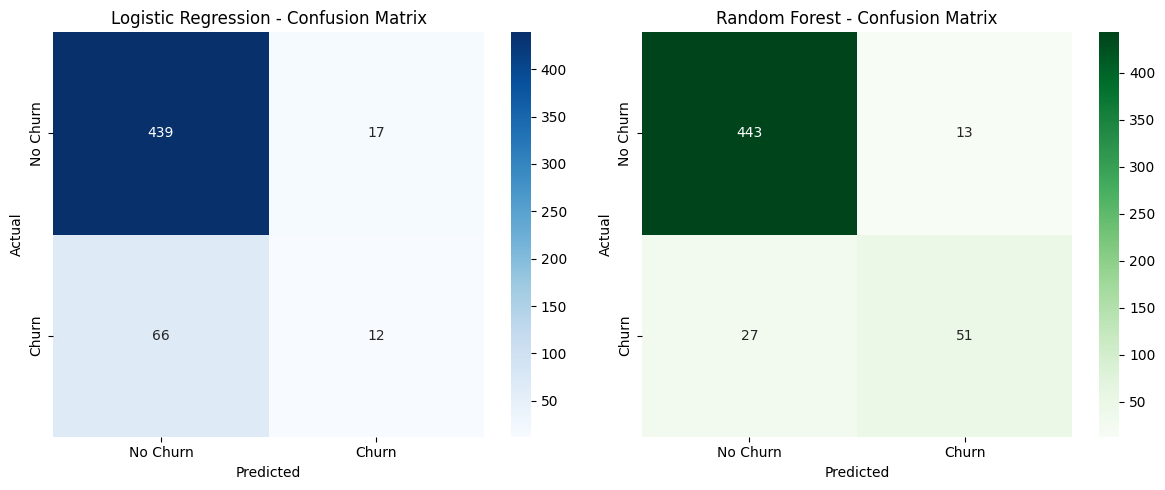

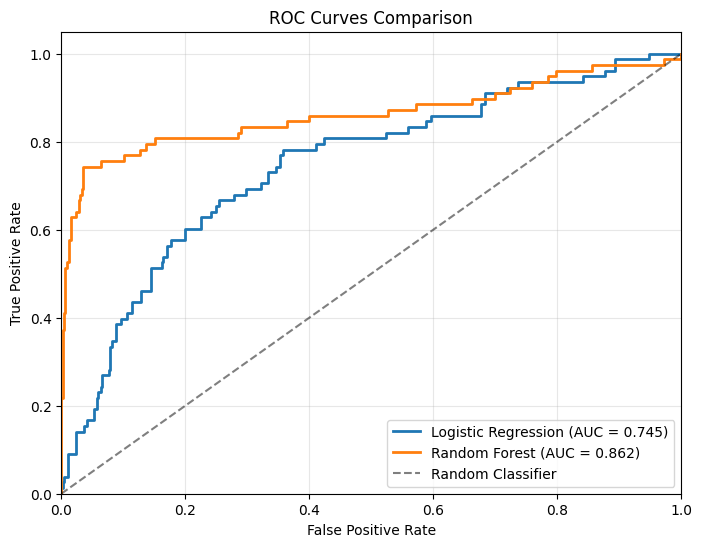

In [15]:
# Cell 12: Visualize Model Performance
# Create confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression - Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticklabels(['No Churn', 'Churn'])
axes[0].set_yticklabels(['No Churn', 'Churn'])

# Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Random Forest - Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_xticklabels(['No Churn', 'Churn'])
axes[1].set_yticklabels(['No Churn', 'Churn'])

plt.tight_layout()
plt.show()

# ROC Curves
plt.figure(figsize=(8, 6))

# Logistic Regression ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_pred_proba)
roc_auc_lr = roc_auc_score(y_test, lr_pred_proba)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})', linewidth=2)

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_pred_proba)
roc_auc_rf = roc_auc_score(y_test, rf_pred_proba)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.3f})', linewidth=2)

# Diagonal line
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', alpha=0.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

Model Performance Comparison:
                 Model  Accuracy   ROC-AUC
0  Logistic Regression  0.844569  0.745445
1        Random Forest  0.925094  0.861926


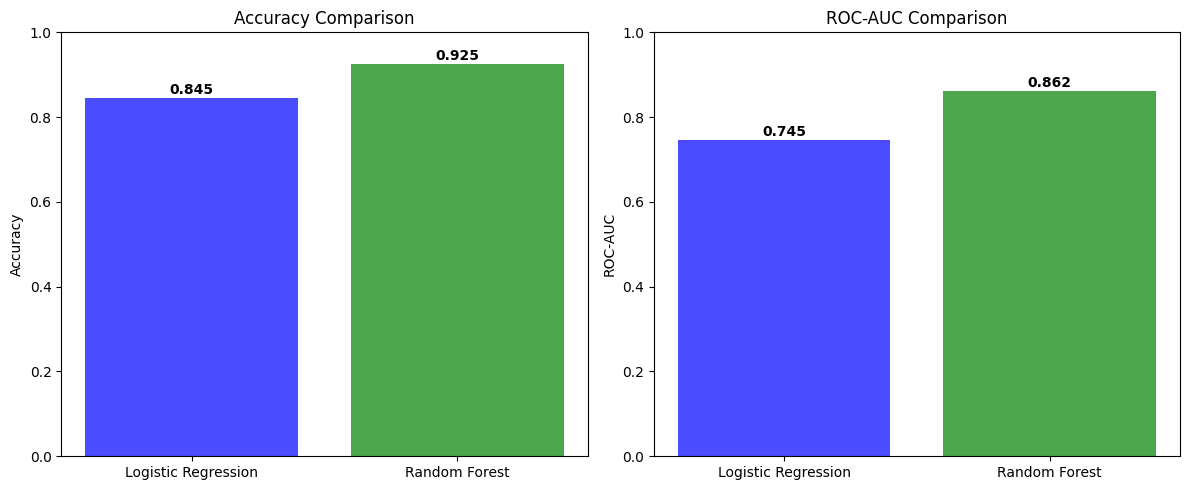

In [16]:
# Cell 13: Compare Model Performance
models = ['Logistic Regression', 'Random Forest']
accuracy_scores = [accuracy_score(y_test, lr_pred), accuracy_score(y_test, rf_pred)]
auc_scores = [roc_auc_score(y_test, lr_pred_proba), roc_auc_score(y_test, rf_pred_proba)]

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracy_scores,
    'ROC-AUC': auc_scores
})

print("Model Performance Comparison:")
print(comparison_df)

# Visualize comparison
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy comparison
bars1 = ax[0].bar(models, accuracy_scores, color=['blue', 'green'], alpha=0.7)
ax[0].set_title('Accuracy Comparison')
ax[0].set_ylabel('Accuracy')
ax[0].set_ylim([0, 1])
for i, v in enumerate(accuracy_scores):
    ax[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

# ROC-AUC comparison
bars2 = ax[1].bar(models, auc_scores, color=['blue', 'green'], alpha=0.7)
ax[1].set_title('ROC-AUC Comparison')
ax[1].set_ylabel('ROC-AUC')
ax[1].set_ylim([0, 1])
for i, v in enumerate(auc_scores):
    ax[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Cell 14: Select Best Model and Export Pipeline
# Select the best model based on ROC-AUC score
if auc_scores[0] > auc_scores[1]:
    best_model = lr_best_model
    best_model_name = 'Logistic_Regression'
    print(f"Best Model: Logistic Regression (ROC-AUC: {auc_scores[0]:.4f})")
else:
    best_model = rf_best_model
    best_model_name = 'Random_Forest'
    print(f"Best Model: Random Forest (ROC-AUC: {auc_scores[1]:.4f})")

# Export the complete pipeline
import os
model_filename = f'best_churn_prediction_pipeline_{best_model_name}.joblib'
joblib.dump(best_model, model_filename)

print(f"\nModel exported successfully as: {model_filename}")
print(f"File size: {round(os.path.getsize(model_filename) / (1024 * 1024), 2)} MB")